# Inventory Forecasting - Inventory Recommendations

 ## Objectives
 1. Generate demand forecasts using trained model.
 2. Calculate optimal inventory levels.
 3. Provide actionable recommendations.
 4. Visualize inventory optimization results.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib
import warnings
warnings.filterwarnings('ignore')



In [3]:
# Load trained model and data
print("Loading model and data...")
model = joblib.load('../models/best_model_GradientBoosting.pkl')  # Adjust based on your best model
df = pd.read_csv('../data/engineered_features.csv')
feature_columns = [col for col in df.columns if col not in [
    'Date', 'Bar Name', 'Alcohol Type', 'Brand Name', 
    'Next_Day_Consumption', 'Consumed (ml)', 'Purchase (ml)',
    'Opening Balance (ml)', 'Closing Balance (ml)'
]]

print(f"Model loaded: {type(model).__name__}")
print(f"Data shape: {df.shape}")

Loading model and data...
Model loaded: GradientBoostingRegressor
Data shape: (6479, 52)


In [4]:
class InventoryOptimizer:
    def __init__(self, service_level=0.95):
        self.service_level = service_level
        self.z_score = stats.norm.ppf(service_level)
    
    def calculate_safety_stock(self, demand_std, lead_time=1, lead_time_std=0):
        """Calculate safety stock based on demand variability"""
        safety_stock = self.z_score * np.sqrt(
            lead_time * demand_std**2 + lead_time_std**2 * demand_std**2
        )
        return max(safety_stock, 0)
    
    def calculate_reorder_point(self, forecast_demand, safety_stock, lead_time=1):
        """Calculate reorder point"""
        return forecast_demand * lead_time + safety_stock
    
    def calculate_par_level(self, forecast_demand, demand_std, lead_time=1, review_period=1):
        """Calculate par level (target inventory level)"""
        safety_stock = self.calculate_safety_stock(demand_std, lead_time)
        par_level = forecast_demand * (lead_time + review_period) + safety_stock
        return max(par_level, forecast_demand)

In [5]:
# Generate forecasts for all items
print("Generating demand forecasts...")
X = df[feature_columns]
forecasts = model.predict(X)

forecasts_df = df[['Date', 'Bar Name', 'Alcohol Type', 'Brand Name', 'Consumed (ml)']].copy()
forecasts_df['Forecasted_Demand'] = forecasts
forecasts_df['Date'] = pd.to_datetime(forecasts_df['Date'])

print(f"Forecasts generated for {len(forecasts_df)} records")

Generating demand forecasts...
Forecasts generated for 6479 records


In [6]:
# Calculate historical demand statistics
print("Calculating demand statistics...")
demand_stats = df.groupby(['Bar Name', 'Alcohol Type', 'Brand Name']).agg({
    'Consumed (ml)': ['mean', 'std', 'min', 'max', 'count']
}).round(2)

demand_stats.columns = ['Avg_Demand', 'Std_Demand', 'Min_Demand', 'Max_Demand', 'Record_Count']
demand_stats = demand_stats.reset_index()

Calculating demand statistics...


In [7]:
# Merge forecasts with historical stats
optimization_data = forecasts_df.groupby(['Bar Name', 'Alcohol Type', 'Brand Name']).agg({
    'Forecasted_Demand': 'mean'
}).reset_index()

optimization_data = optimization_data.merge(demand_stats, on=['Bar Name', 'Alcohol Type', 'Brand Name'])
optimization_data['Coefficient_of_Variation'] = (optimization_data['Std_Demand'] / 
                                                optimization_data['Avg_Demand']).replace([np.inf, -np.inf], 0)

print(f"Optimization data prepared for {len(optimization_data)} items")


Optimization data prepared for 96 items


In [8]:
# Generate inventory recommendations
print("Generating inventory recommendations...")
optimizer = InventoryOptimizer(service_level=0.95)

recommendations = []
for _, row in optimization_data.iterrows():
    forecast_demand = row['Forecasted_Demand']
    demand_std = row['Std_Demand'] if not pd.isna(row['Std_Demand']) else forecast_demand * 0.1
    
    # Calculate optimal levels
    safety_stock = optimizer.calculate_safety_stock(demand_std)
    reorder_point = optimizer.calculate_reorder_point(forecast_demand, safety_stock)
    par_level = optimizer.calculate_par_level(forecast_demand, demand_std)
    
    # Demand variability category
    cv = row['Coefficient_of_Variation']
    if cv < 0.3:
        variability = 'Low'
    elif cv < 0.6:
        variability = 'Medium'
    else:
        variability = 'High'
    
    recommendations.append({
        'Bar_Name': row['Bar Name'],
        'Alcohol_Type': row['Alcohol Type'],
        'Brand_Name': row['Brand Name'],
        'Forecasted_Daily_Demand': round(forecast_demand, 2),
        'Historical_Avg_Demand': row['Avg_Demand'],
        'Demand_Std': round(demand_std, 2),
        'Coefficient_of_Variation': round(cv, 2),
        'Demand_Variability': variability,
        'Safety_Stock': round(safety_stock, 2),
        'Reorder_Point': round(reorder_point, 2),
        'Par_Level': round(par_level, 2),
        'Record_Count': row['Record_Count']
    })

recommendations_df = pd.DataFrame(recommendations)
print(f"Inventory recommendations generated for {len(recommendations_df)} items")

# %%
# Save recommendations
recommendations_df.to_csv('../results/inventory_recommendations.csv', index=False)
print("Recommendations saved to '../results/inventory_recommendations.csv'")

Generating inventory recommendations...
Inventory recommendations generated for 96 items
Recommendations saved to '../results/inventory_recommendations.csv'


In [9]:
# Analysis and Visualization

# 1. Summary statistics
print("\n=== INVENTORY RECOMMENDATIONS SUMMARY ===")
print(f"Total items: {len(recommendations_df)}")
print(f"Average safety stock: {recommendations_df['Safety_Stock'].mean():.2f} ml")
print(f"Average par level: {recommendations_df['Par_Level'].mean():.2f} ml")
print(f"Demand variability distribution:")
print(recommendations_df['Demand_Variability'].value_counts())


=== INVENTORY RECOMMENDATIONS SUMMARY ===
Total items: 96
Average safety stock: 306.83 ml
Average par level: 909.83 ml
Demand variability distribution:
Demand_Variability
Medium    53
High      43
Name: count, dtype: int64


(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, "Johnson's Bar"),
  Text(1, 0, "Anderson's Bar"),
  Text(2, 0, "Smith's Bar"),
  Text(3, 0, "Brown's Bar"),
  Text(4, 0, "Thomas's Bar"),
  Text(5, 0, "Taylor's Bar")])

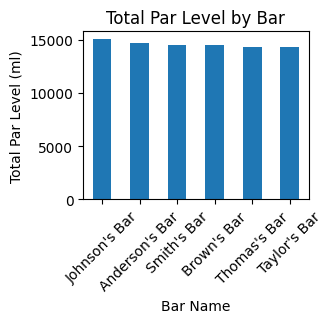

In [10]:
# Par levels by bar
plt.subplot(2, 2, 1)
bar_par_levels = recommendations_df.groupby('Bar_Name')['Par_Level'].sum().sort_values(ascending=False)
bar_par_levels.plot(kind='bar')
plt.title('Total Par Level by Bar')
plt.xlabel('Bar Name')
plt.ylabel('Total Par Level (ml)')
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, "Thomas's Bar"),
  Text(1, 0, "Taylor's Bar"),
  Text(2, 0, "Anderson's Bar"),
  Text(3, 0, "Brown's Bar"),
  Text(4, 0, "Johnson's Bar"),
  Text(5, 0, "Smith's Bar")])

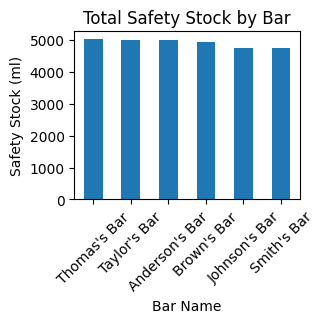

In [11]:
# Safety stock by bar
plt.subplot(2, 2, 2)
bar_safety_stock = recommendations_df.groupby('Bar_Name')['Safety_Stock'].sum().sort_values(ascending=False)
bar_safety_stock.plot(kind='bar')
plt.title('Total Safety Stock by Bar')
plt.xlabel('Bar Name')
plt.ylabel('Safety Stock (ml)')
plt.xticks(rotation=45)


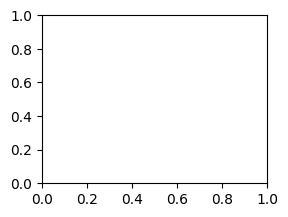

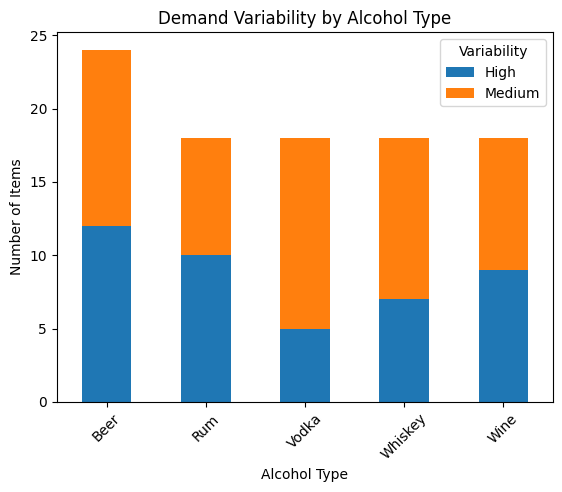

In [12]:
# Demand variability by alcohol type
plt.subplot(2, 2, 3)
variability_by_type = pd.crosstab(recommendations_df['Alcohol_Type'], recommendations_df['Demand_Variability'])
variability_by_type.plot(kind='bar', stacked=True)
plt.title('Demand Variability by Alcohol Type')
plt.xlabel('Alcohol Type')
plt.ylabel('Number of Items')
plt.xticks(rotation=45)
plt.legend(title='Variability')

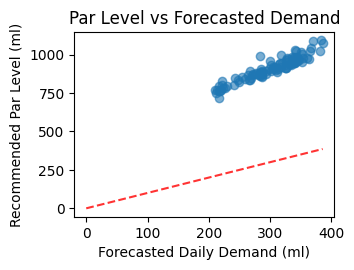

In [13]:
# Par level vs demand
plt.subplot(2, 2, 4)
plt.scatter(recommendations_df['Forecasted_Daily_Demand'], recommendations_df['Par_Level'], alpha=0.6)
plt.plot([0, recommendations_df['Forecasted_Daily_Demand'].max()], 
         [0, recommendations_df['Forecasted_Daily_Demand'].max()], 'r--', alpha=0.8)
plt.xlabel('Forecasted Daily Demand (ml)')
plt.ylabel('Recommended Par Level (ml)')
plt.title('Par Level vs Forecasted Demand')

plt.tight_layout()
plt.show()

In [14]:
# 3. Top and bottom items by par level
print("\n=== TOP 10 ITEMS BY PAR LEVEL ===")
top_items = recommendations_df.nlargest(10, 'Par_Level')[[
    'Bar_Name', 'Alcohol_Type', 'Brand_Name', 'Forecasted_Daily_Demand', 'Par_Level'
]]
print(top_items.round(2))

print("\n=== BOTTOM 10 ITEMS BY PAR LEVEL ===")
bottom_items = recommendations_df.nsmallest(10, 'Par_Level')[[
    'Bar_Name', 'Alcohol_Type', 'Brand_Name', 'Forecasted_Daily_Demand', 'Par_Level'
]]
print(bottom_items.round(2))


=== TOP 10 ITEMS BY PAR LEVEL ===
          Bar_Name Alcohol_Type      Brand_Name  Forecasted_Daily_Demand  \
5   Anderson's Bar          Rum  Captain Morgan                   383.73   
83    Thomas's Bar         Beer          Miller                   370.04   
32   Johnson's Bar         Beer       Budweiser                   385.68   
64    Taylor's Bar         Beer       Budweiser                   366.70   
14  Anderson's Bar         Wine     Sutter Home                   340.44   
69    Taylor's Bar          Rum  Captain Morgan                   342.28   
41   Johnson's Bar        Vodka        Smirnoff                   365.10   
38   Johnson's Bar          Rum          Malibu                   381.68   
42   Johnson's Bar      Whiskey    Jack Daniels                   350.36   
56     Smith's Bar        Vodka      Grey Goose                   352.71   

    Par_Level  
5     1091.54  
83    1085.29  
32    1077.58  
64    1042.51  
14    1029.00  
69    1024.75  
41    1023.66  


In [15]:
# 4. Cost-saving analysis
# Compare current practice (assuming simple heuristics) vs optimized

# Simple heuristic: 3 days of average demand
recommendations_df['Simple_Heuristic'] = recommendations_df['Historical_Avg_Demand'] * 3
recommendations_df['Optimization_Saving'] = recommendations_df['Simple_Heuristic'] - recommendations_df['Par_Level']

total_simple_inventory = recommendations_df['Simple_Heuristic'].sum()
total_optimized_inventory = recommendations_df['Par_Level'].sum()
total_saving = total_simple_inventory - total_optimized_inventory
saving_percentage = (total_saving / total_simple_inventory) * 100

print(f"\n=== COST SAVING ANALYSIS ===")
print(f"Total inventory under simple heuristic: {total_simple_inventory:,.0f} ml")
print(f"Total inventory under optimization: {total_optimized_inventory:,.0f} ml")
print(f"Total inventory reduction: {total_saving:,.0f} ml ({saving_percentage:.1f}%)")


=== COST SAVING ANALYSIS ===
Total inventory under simple heuristic: 86,533 ml
Total inventory under optimization: 87,344 ml
Total inventory reduction: -811 ml (-0.9%)


In [16]:
# 5. Stockout risk analysis
# Items with high demand variability and low safety stock
high_risk_items = recommendations_df[
    (recommendations_df['Demand_Variability'] == 'High') & 
    (recommendations_df['Safety_Stock'] < recommendations_df['Forecasted_Daily_Demand'])
]

print(f"\n=== HIGH-RISK ITEMS ANALYSIS ===")
print(f"Number of high-risk items: {len(high_risk_items)}")
if len(high_risk_items) > 0:
    print("\nHigh-risk items (may need higher safety stock):")
    print(high_risk_items[['Bar_Name', 'Alcohol_Type', 'Brand_Name', 
                          'Forecasted_Daily_Demand', 'Safety_Stock', 'Demand_Variability']].round(2))


=== HIGH-RISK ITEMS ANALYSIS ===
Number of high-risk items: 3

High-risk items (may need higher safety stock):
         Bar_Name Alcohol_Type      Brand_Name  Forecasted_Daily_Demand  \
37  Johnson's Bar          Rum  Captain Morgan                   302.05   
65   Taylor's Bar         Beer           Coors                   287.53   
69   Taylor's Bar          Rum  Captain Morgan                   342.28   

    Safety_Stock Demand_Variability  
37        290.05               High  
65        286.55               High  
69        340.19               High  


In [17]:
# 6. Implementation roadmap
print("\n=== IMPLEMENTATION ROADMAP ===")

# Phase 1: High-impact items
high_impact_items = recommendations_df.nlargest(20, 'Forecasted_Daily_Demand')
print("PHASE 1 - High Impact Items (Top 20 by demand):")
print(f"  - Items: {len(high_impact_items)}")
print(f"  - Total par level: {high_impact_items['Par_Level'].sum():,.0f} ml")
print(f"  - Focus: {high_impact_items['Alcohol_Type'].value_counts().to_dict()}")

# Phase 2: High-variability items
high_variability_items = recommendations_df[recommendations_df['Demand_Variability'] == 'High']
print("\nPHASE 2 - High Variability Items:")
print(f"  - Items: {len(high_variability_items)}")
print(f"  - Focus on demand stabilization and safety stock")

# Phase 3: Remaining items
remaining_items = len(recommendations_df) - len(high_impact_items) - len(high_variability_items)
print(f"\nPHASE 3 - Remaining Items:")
print(f"  - Items: {remaining_items}")
print(f"  - Standard implementation")


=== IMPLEMENTATION ROADMAP ===
PHASE 1 - High Impact Items (Top 20 by demand):
  - Items: 20
  - Total par level: 20,038 ml
  - Focus: {'Beer': 8, 'Rum': 4, 'Vodka': 4, 'Whiskey': 2, 'Wine': 2}

PHASE 2 - High Variability Items:
  - Items: 43
  - Focus on demand stabilization and safety stock

PHASE 3 - Remaining Items:
  - Items: 33
  - Standard implementation


In [18]:
# 7. Bar-specific recommendations
print("\n=== BAR-SPECIFIC SUMMARIES ===")
for bar in recommendations_df['Bar_Name'].unique():
    bar_data = recommendations_df[recommendations_df['Bar_Name'] == bar]
    print(f"\n{bar}:")
    print(f"  - Total items: {len(bar_data)}")
    print(f"  - Total par level: {bar_data['Par_Level'].sum():,.0f} ml")
    print(f"  - Top alcohol type: {bar_data['Alcohol_Type'].value_counts().idxmax()}")
    print(f"  - High variability items: {len(bar_data[bar_data['Demand_Variability'] == 'High'])}")


=== BAR-SPECIFIC SUMMARIES ===

Anderson's Bar:
  - Total items: 16
  - Total par level: 14,658 ml
  - Top alcohol type: Beer
  - High variability items: 7

Brown's Bar:
  - Total items: 16
  - Total par level: 14,500 ml
  - Top alcohol type: Beer
  - High variability items: 8

Johnson's Bar:
  - Total items: 16
  - Total par level: 15,029 ml
  - Top alcohol type: Beer
  - High variability items: 5

Smith's Bar:
  - Total items: 16
  - Total par level: 14,554 ml
  - Top alcohol type: Beer
  - High variability items: 4

Taylor's Bar:
  - Total items: 16
  - Total par level: 14,302 ml
  - Top alcohol type: Beer
  - High variability items: 10

Thomas's Bar:
  - Total items: 16
  - Total par level: 14,302 ml
  - Top alcohol type: Beer
  - High variability items: 9


In [19]:
# Save detailed analysis
analysis_summary = {
    'total_items': len(recommendations_df),
    'total_par_level': recommendations_df['Par_Level'].sum(),
    'total_safety_stock': recommendations_df['Safety_Stock'].sum(),
    'inventory_reduction_ml': total_saving,
    'inventory_reduction_percent': saving_percentage,
    'high_risk_items_count': len(high_risk_items),
    'high_variability_items_count': len(high_variability_items)
}

import json
with open('../results/analysis_summary.json', 'w') as f:
    json.dump(analysis_summary, f, indent=2)

print("\n=== INVENTORY OPTIMIZATION COMPLETED ===")
print("✅ Demand forecasts generated")
print("✅ Safety stock calculated")
print("✅ Reorder points established") 
print("✅ Par levels recommended")
print("✅ Cost savings quantified")
print("✅ Implementation roadmap created")
print("\nAll results saved to '../results/' folder")



=== INVENTORY OPTIMIZATION COMPLETED ===
✅ Demand forecasts generated
✅ Safety stock calculated
✅ Reorder points established
✅ Par levels recommended
✅ Cost savings quantified
✅ Implementation roadmap created

All results saved to '../results/' folder
